In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix ,classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn import tree
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import   KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split 
from sklearn.naive_bayes import BernoulliNB
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from joblib import dump



In [2]:
df = pd.read_csv("preprocessed_global_air_pollution_dataset.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23035 entries, 0 to 23034
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Country             23035 non-null  object
 1   AQI Value           23035 non-null  int64 
 2   AQI Category        23035 non-null  object
 3   CO AQI Value        23035 non-null  int64 
 4   CO AQI Category     23035 non-null  object
 5   Ozone AQI Value     23035 non-null  int64 
 6   Ozone AQI Category  23035 non-null  object
 7   NO2 AQI Value       23035 non-null  int64 
 8   NO2 AQI Category    23035 non-null  object
 9   PM2.5 AQI Value     23035 non-null  int64 
 10  PM2.5 AQI Category  23035 non-null  object
dtypes: int64(5), object(6)
memory usage: 1.9+ MB


In [4]:
df.shape

(23035, 11)

## Feature Engineering

## feature Selection

In [5]:
# feature Selection
df_selection= df.drop(columns=[
"AQI Value",
"CO AQI Category",
"Ozone AQI Category",
"NO2 AQI Category",
"PM2.5 AQI Category"
])

## Feature Extraction

In [6]:
df_selection['pollution_mean'] = df_selection[['CO AQI Value','Ozone AQI Value','NO2 AQI Value','PM2.5 AQI Value']].mean(axis=1)

In [7]:
df_selection.columns

Index(['Country', 'AQI Category', 'CO AQI Value', 'Ozone AQI Value',
       'NO2 AQI Value', 'PM2.5 AQI Value', 'pollution_mean'],
      dtype='object')

In [51]:
df_selection.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23035 entries, 0 to 23034
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Country          23035 non-null  object 
 1   AQI Category     23035 non-null  object 
 2   CO AQI Value     23035 non-null  int64  
 3   Ozone AQI Value  23035 non-null  int64  
 4   NO2 AQI Value    23035 non-null  int64  
 5   PM2.5 AQI Value  23035 non-null  int64  
 6   pollution_mean   23035 non-null  float64
dtypes: float64(1), int64(4), object(2)
memory usage: 1.2+ MB


## Split Data

In [9]:
X = df_selection.drop(columns=["AQI Category"]) 
y = df_selection['AQI Category']

In [10]:
X_train, X_test, y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=42 , stratify= y)

In [11]:
X_train.shape , y_train.shape , X_test.shape , y_test.shape

((18428, 6), (18428,), (4607, 6), (4607,))

## Features Transformation

In [12]:
# Identify numeric columns
numerical_cols = X.select_dtypes(include=["float64", "int64"]).columns.to_list()
category_cols = X.select_dtypes(include=["object"]).columns.to_list()

In [13]:
#Create a pipeline for numerical features
num_pipeline = Pipeline(steps=[
     ('imputer', SimpleImputer(strategy='median')),
   ( "scalar",StandardScaler())])

cata_pipeline = Pipeline(steps= [ ('imputer', SimpleImputer(strategy='most_frequent'))
                                 , ('onehot', OneHotEncoder(handle_unknown='ignore'))])

In [14]:
# Combine numerical and categorical pipelines using ColumnTransformer

transformations = ColumnTransformer (
    transformers =[
        ("num_pipeline",num_pipeline,numerical_cols ),
        ("cata_pipeline",cata_pipeline,category_cols)
    ]

)

In [15]:
# Transform the train data
X_train_processed = transformations.fit_transform(X_train)

In [16]:
X_test_processed = transformations.transform(X_test)

In [17]:
X_train_processed.shape , X_test_processed.shape

((18428, 178), (4607, 178))

In [18]:
dump(transformations, "../src/artifacts/transformations.pkl")

['../src/artifacts/transformations.pkl']

## label encodeing target

In [19]:
target_encoder = LabelEncoder()
y_train_encoded = target_encoder.fit_transform(y_train)
y_test_encoded = target_encoder.transform(y_test)




In [20]:
y_train_encoded.shape , y_test_encoded.shape

((18428,), (4607,))

In [21]:
y_train_encoded

array([4, 0, 2, ..., 0, 0, 2])

In [22]:
target_encoder.classes_

array(['Good', 'Hazardous', 'Moderate', 'Unhealthy',
       'Unhealthy for Sensitive Groups', 'Very Unhealthy'], dtype=object)

In [23]:
dump(target_encoder, "../src/artifacts/target_encoder.pkl")

['../src/artifacts/target_encoder.pkl']

## model

# Evaluation Function

In [24]:
def evaluate_classification_model(x_test_scaled, y_true, predictor, y_pred=None):
    # Handle KNN with batch prediction to avoid memory errors
    if y_pred is None:
        if isinstance(predictor, KNeighborsClassifier):
            batch_size = 100  # Small batch size for memory efficiency
            y_pred_batches = []
            for i in range(0, x_test_scaled.shape[0], batch_size):
                batch = x_test_scaled[i:i+batch_size]
                y_pred_batches.append(predictor.predict(batch))
            y_pred = np.concatenate(y_pred_batches)
        else:
            y_pred = predictor.predict(x_test_scaled)

    # Compute Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    # Compute Classification Report (includes Precision, Recall, F1-Score, Support)
    cr = classification_report(y_true, y_pred)

    # Compute Accuracy Score
    accuracy = accuracy_score(y_true, y_pred)

    print("="*30)
    print("Evaluation Metrics:")
    print("\nConfusion Matrix:")
    print(cm)

    # Visualize the confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_encoder.classes_, yticklabels=target_encoder.classes_)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

    print("\nClassification Report:")
    print(cr)
    print(f"\nAccuracy: {accuracy:.4f}")
    print("="*30)

# Base Model

## logistic Regression

In [25]:
LR = LogisticRegression(random_state=42)
LR.fit(X_train_processed , y_train_encoded)

c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(random_state=42)

Evaluation Metrics:

Confusion Matrix:
[[1861    0   77    0    0    0]
 [   0   34    0    0    0    4]
 [  58    0 1743    0   16    0]
 [   0    0    0  433   10    0]
 [   0    0   27   36  251    0]
 [   0    2    0   14    0   41]]


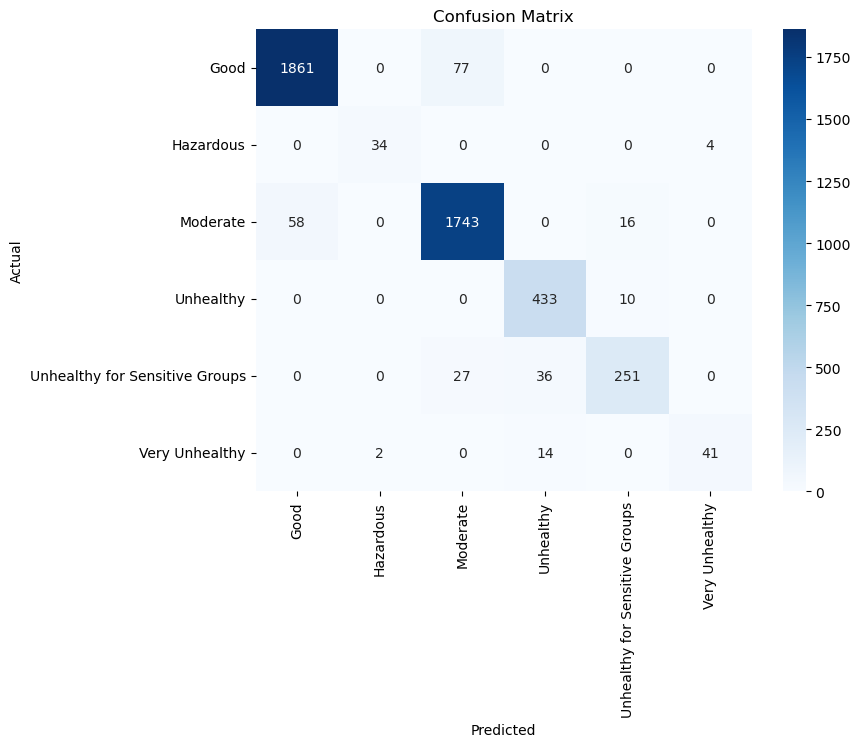


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.96      1938
           1       0.94      0.89      0.92        38
           2       0.94      0.96      0.95      1817
           3       0.90      0.98      0.94       443
           4       0.91      0.80      0.85       314
           5       0.91      0.72      0.80        57

    accuracy                           0.95      4607
   macro avg       0.93      0.89      0.90      4607
weighted avg       0.95      0.95      0.95      4607


Accuracy: 0.9470


In [26]:
evaluate_classification_model(X_test_processed ,y_test_encoded , LR)

## BernoulliNB

In [27]:
Berrnou = BernoulliNB()
Berrnou.fit(X_train_processed, y_train_encoded)

BernoulliNB()

c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Evaluation Metrics:

Confusion Matrix:
[[1780    0  158    0    0    0]
 [   0    0    0   36    2    0]
 [ 618    0  938  111  150    0]
 [   0    0    5  366   72    0]
 [   0    0   38  148  128    0]
 [   0    0    0   46   11    0]]


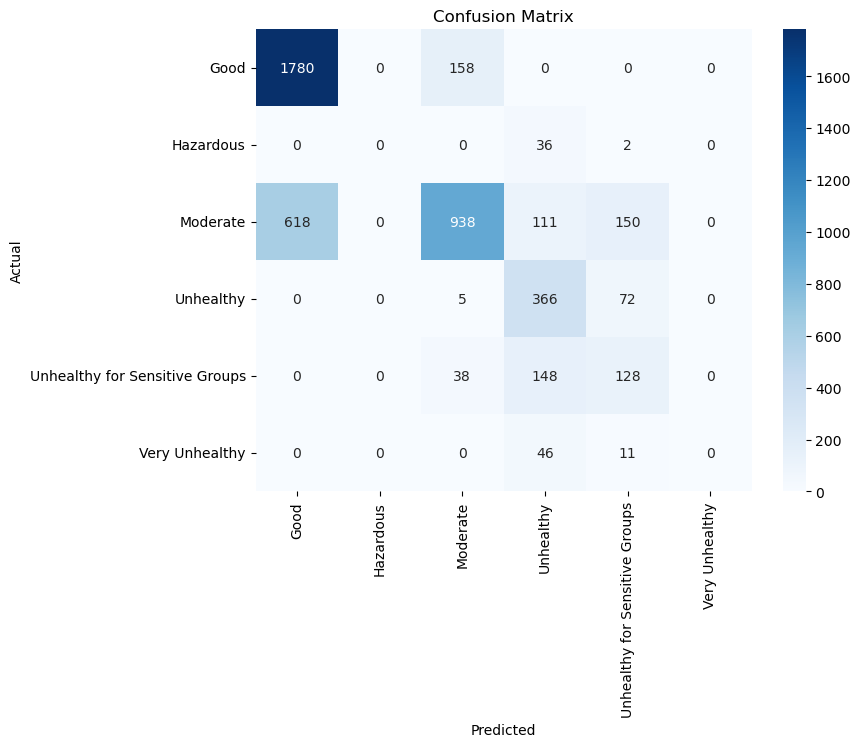


Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.92      0.82      1938
           1       0.00      0.00      0.00        38
           2       0.82      0.52      0.63      1817
           3       0.52      0.83      0.64       443
           4       0.35      0.41      0.38       314
           5       0.00      0.00      0.00        57

    accuracy                           0.70      4607
   macro avg       0.41      0.44      0.41      4607
weighted avg       0.71      0.70      0.68      4607


Accuracy: 0.6972


In [28]:
evaluate_classification_model(X_test_processed ,y_test_encoded , Berrnou)

## KNN

In [29]:
KNN_Classifier = KNeighborsClassifier(n_neighbors=7, p=1, algorithm='auto')
KNN_Classifier.fit(X_train_processed, y_train_encoded)

KNeighborsClassifier(n_neighbors=7, p=1)

the Result in training data
Evaluation Metrics:

Confusion Matrix:
[[1842    0   96    0    0    0]
 [   0   35    0    0    0    3]
 [  70    0 1739    0    8    0]
 [   0    0    0  427   15    1]
 [   0    0   35   27  252    0]
 [   0    3    0   12    0   42]]


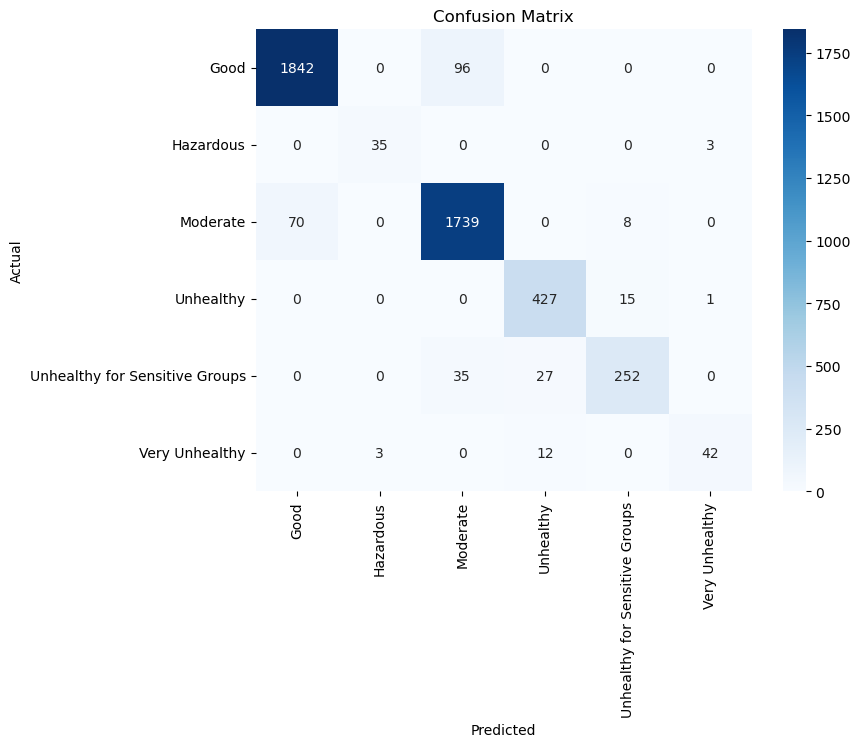


Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.96      1938
           1       0.92      0.92      0.92        38
           2       0.93      0.96      0.94      1817
           3       0.92      0.96      0.94       443
           4       0.92      0.80      0.86       314
           5       0.91      0.74      0.82        57

    accuracy                           0.94      4607
   macro avg       0.93      0.89      0.91      4607
weighted avg       0.94      0.94      0.94      4607


Accuracy: 0.9414


In [43]:
print("the Result in training data")
evaluate_classification_model(X_test_processed, y_test_encoded, KNN_Classifier)

# Random Forest

In [31]:
random_forest = RandomForestClassifier(random_state=42)


In [32]:
random_forest.fit(X_train_processed, y_train_encoded)

RandomForestClassifier(random_state=42)

Evaluation Metrics:

Confusion Matrix:
[[1938    0    0    0    0    0]
 [   0   34    0    0    0    4]
 [   0    0 1816    0    1    0]
 [   0    0    0  442    0    1]
 [   0    0    0    3  311    0]
 [   0    2    0    9    0   46]]


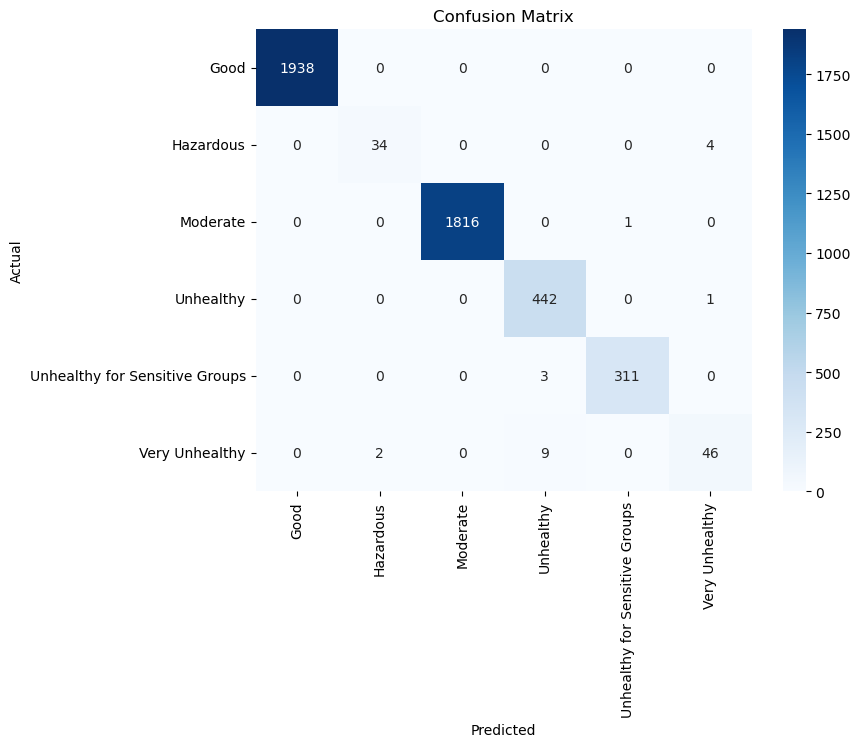


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1938
           1       0.94      0.89      0.92        38
           2       1.00      1.00      1.00      1817
           3       0.97      1.00      0.99       443
           4       1.00      0.99      0.99       314
           5       0.90      0.81      0.85        57

    accuracy                           1.00      4607
   macro avg       0.97      0.95      0.96      4607
weighted avg       1.00      1.00      1.00      4607


Accuracy: 0.9957


In [33]:
evaluate_classification_model(X_test_processed ,y_test_encoded , random_forest)

# Support Vector Machine (SVM)

In [34]:
from sklearn import svm 


In [35]:
svm_classifier = svm.SVC(kernel='linear', random_state=42)


In [36]:
svm_classifier.fit(X_train_processed, y_train_encoded)

SVC(kernel='linear', random_state=42)

Evaluation Metrics:

Confusion Matrix:
[[1878    0   60    0    0    0]
 [   0   34    0    0    0    4]
 [  57    0 1747    0   13    0]
 [   0    0    0  430   10    3]
 [   0    0   14   36  264    0]
 [   0    2    0   11    0   44]]


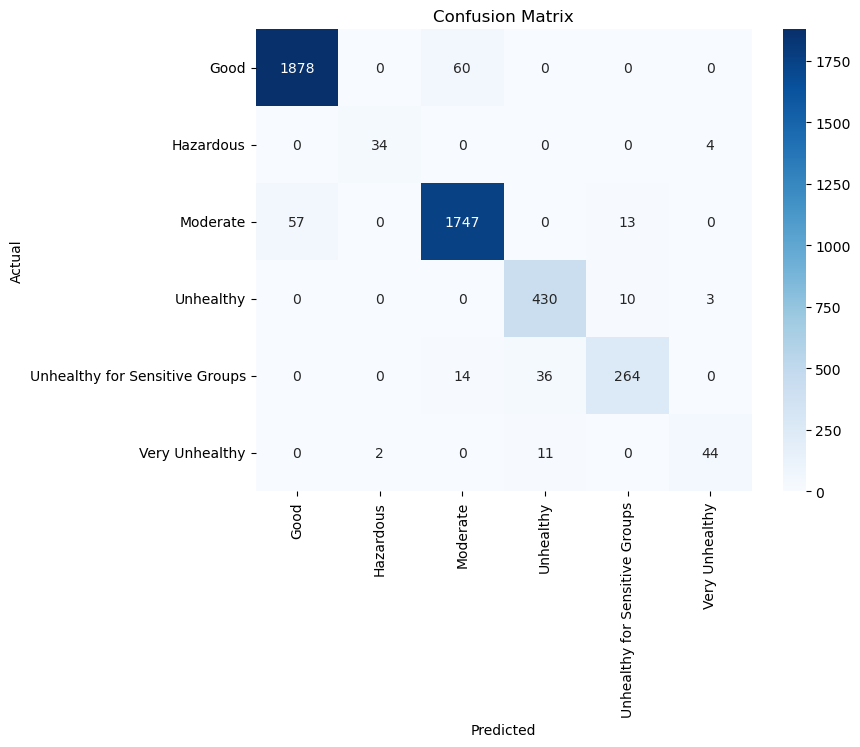


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1938
           1       0.94      0.89      0.92        38
           2       0.96      0.96      0.96      1817
           3       0.90      0.97      0.93       443
           4       0.92      0.84      0.88       314
           5       0.86      0.77      0.81        57

    accuracy                           0.95      4607
   macro avg       0.93      0.90      0.91      4607
weighted avg       0.95      0.95      0.95      4607


Accuracy: 0.9544


In [37]:
evaluate_classification_model(X_test_processed ,y_test_encoded , svm_classifier)

## BEST MODEL

c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


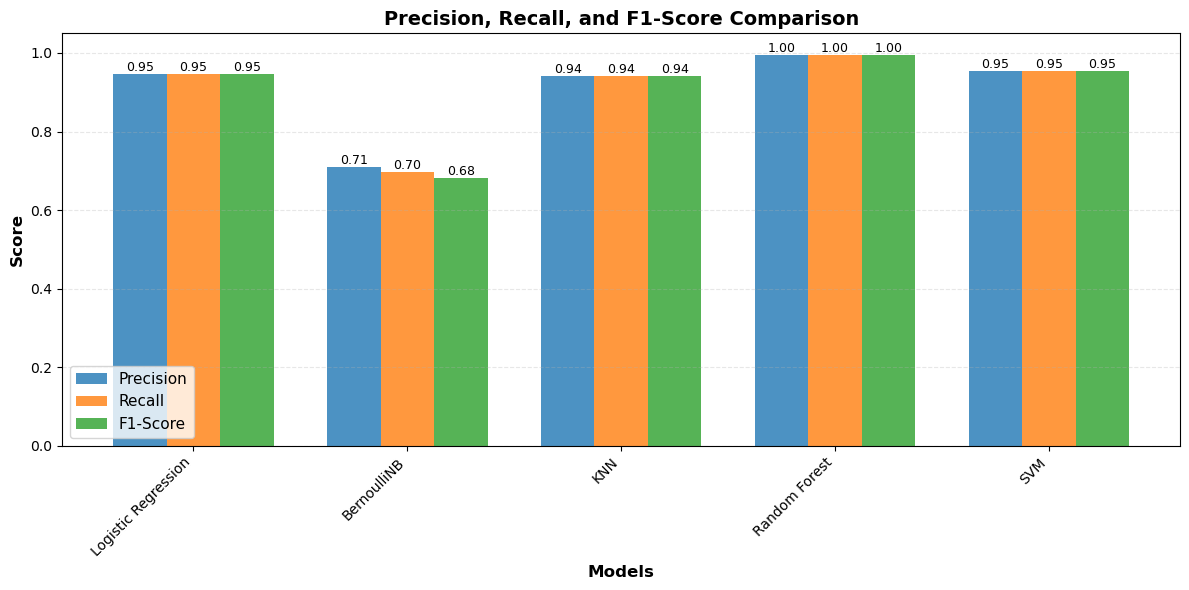

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# Create a bar chart to compare the precision, recall, and F1-score of the models
models = [
    "Logistic Regression",
    "BernoulliNB",
    "KNN",
    "Random Forest",
    "SVM"
]

precision = [
    precision_score(y_test_encoded, LR.predict(X_test_processed), average='weighted'),
    precision_score(y_test_encoded, Berrnou.predict(X_test_processed), average='weighted'),
    precision_score(y_test_encoded, KNN_Classifier.predict(X_test_processed), average='weighted'),
    precision_score(y_test_encoded, random_forest.predict(X_test_processed), average='weighted'),
    precision_score(y_test_encoded, svm_classifier.predict(X_test_processed), average='weighted')
]

recall = [
    recall_score(y_test_encoded, LR.predict(X_test_processed), average='weighted'),
    recall_score(y_test_encoded, Berrnou.predict(X_test_processed), average='weighted'),
    recall_score(y_test_encoded, KNN_Classifier.predict(X_test_processed), average='weighted'),
    recall_score(y_test_encoded, random_forest.predict(X_test_processed), average='weighted'),
    recall_score(y_test_encoded, svm_classifier.predict(X_test_processed), average='weighted')
]

f1 = [
    f1_score(y_test_encoded, LR.predict(X_test_processed), average='weighted'),
    f1_score(y_test_encoded, Berrnou.predict(X_test_processed), average='weighted'),
    f1_score(y_test_encoded, KNN_Classifier.predict(X_test_processed), average='weighted'),
    f1_score(y_test_encoded, random_forest.predict(X_test_processed), average='weighted'),
    f1_score(y_test_encoded, svm_classifier.predict(X_test_processed), average='weighted')
]

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(models))  # Label locations
width = 0.25  # Width of bars

# Create bars
bars1 = ax.bar(x - width, precision, width, label='Precision', alpha=0.8)
bars2 = ax.bar(x, recall, width, label='Recall', alpha=0.8)
bars3 = ax.bar(x + width, f1, width, label='F1-Score', alpha=0.8)

# Add labels and title
ax.set_xlabel('Models', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Precision, Recall, and F1-Score Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha='right')
ax.legend(fontsize=11)
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=9)

add_value_labels(bars1)
add_value_labels(bars2)
add_value_labels(bars3)

plt.tight_layout()
plt.show()

the best model is decision tree  no missclassifition


In [46]:
#dump the best model

dump(random_forest, '../src/artifacts/best_model.joblib')

['../src/artifacts/best_model.joblib']

## Inference 

In [47]:
import joblib

transformations = joblib.load('../src/artifacts/transformations.pkl')
target_encoder = joblib.load('../src/artifacts/target_encoder.pkl')
model = joblib.load('../src/artifacts/best_model.joblib')

In [48]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Extract additional features: Max_Pollutant, High_Pollutant_Count
    """
    
    
    df['pollution_mean'] = df[['CO AQI Value','Ozone AQI Value','NO2 AQI Value','PM2.5 AQI Value']].mean(axis=1) 
    return df

def predict_aqi_category(input_data):
    """
    input_data: Dictionary or DataFrame with raw user inputs
    Returns: predicted AQI Category
    """
    # Convert dict to DataFrame if necessary
    if isinstance(input_data, dict):
        input_data = pd.DataFrame([input_data])
    
    # Add default AQI Value if not provided (use max of pollutant values)
    if 'AQI Value' not in input_data.columns:
        input_data['AQI Value'] = input_data[['CO AQI Value','Ozone AQI Value','NO2 AQI Value','PM2.5 AQI Value']].max(axis=1)
    
    # Step 1: Add features automatically
    df_features = add_features(input_data.copy())
    
    # Step 2: Transform features
    X_processed = transformations.transform(df_features)
    
    # Step 3: Predict and decode
    preds_encoded = model.predict(X_processed)
    preds = target_encoder.inverse_transform(preds_encoded)
    
    return preds


In [49]:
# Example usage:

predict_aqi_category({
    "Country": "Russian Federation",
    "CO AQI Value": 1,
    
    "Ozone AQI Value": 36,
    
    "NO2 AQI Value": 0,
   
    "PM2.5 AQI Value": 551,
    
  
})

array(['Unhealthy for Sensitive Groups'], dtype=object)